In [2]:
import mglearn

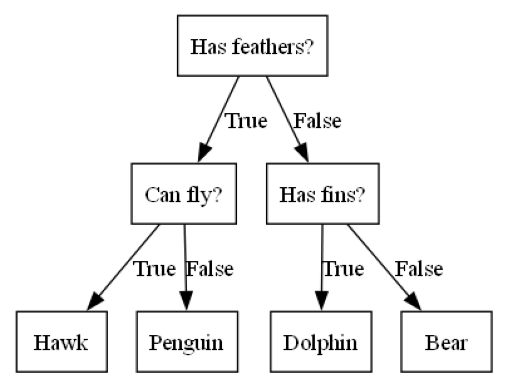

In [3]:
mglearn.plots.plot_animal_tree()

# iris dataset and Decision trees

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=42)

In [5]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier().fit(X_train, y_train)

Visualizing

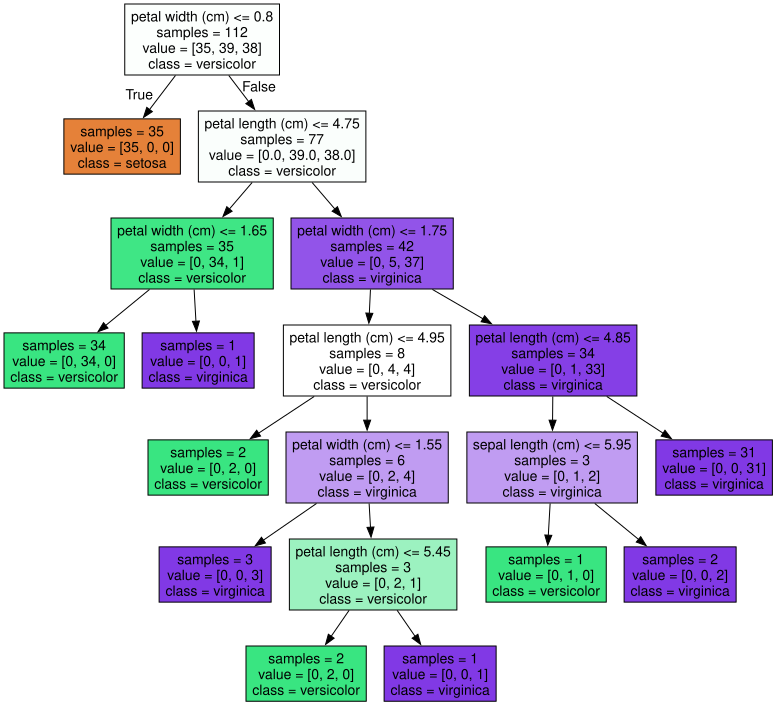

In [7]:
from sklearn.tree import export_graphviz
import graphviz
export_graphviz(dtc, out_file='tree.dot', class_names=['setosa', 'versicolor', 'virginica'], feature_names=iris.feature_names, filled=True, impurity=False)

with open('tree.dot') as f:
    dot_struct = f.read()

graphviz.Source(dot_struct)

# Pre pruning  effects on generalizability of decision tree models using breast cancer dataset

In [8]:
from sklearn.datasets import load_breast_cancer
bc_data = load_breast_cancer()

In [10]:
bc_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [14]:
bc_data['feature_names']

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [17]:
bc_data["target_names"]

array(['malignant', 'benign'], dtype='<U9')

In [19]:
bc_data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [20]:
bc_data['DESCR']

'.. _breast_cancer_dataset:\n\nBreast cancer Wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [34]:
X_train, X_test, y_train, y_test = train_test_split(bc_data["data"], bc_data["target"], random_state=42)

In [35]:
bc_model = DecisionTreeClassifier().fit(X_train, y_train)
bc_model4 = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train)

evaluation

In [36]:
print("bc_model")
print(f"Training set accuracy: {bc_model.score(X_train, y_train)}")
print(f"Generalizability: {bc_model.score(X_test, y_test)}")

bc_model
Training set accuracy: 1.0
Generalizability: 0.9370629370629371


In [37]:
print("bc_model4")
print(f"Training set accuracy: {bc_model4.score(X_train, y_train)}")
print(f"Generalizability: {bc_model4.score(X_test, y_test)}")

bc_model4
Training set accuracy: 0.9953051643192489
Generalizability: 0.951048951048951


In [38]:
export_graphviz(bc_model, out_file="bc_tree.dot", class_names=bc_data["target_names"], feature_names=bc_data["feature_names"], filled=True, impurity=False)

In [39]:
export_graphviz(bc_model4, out_file="bc_tree4.dot", class_names=bc_data["target_names"], feature_names=bc_data["feature_names"], filled=True, impurity=False)

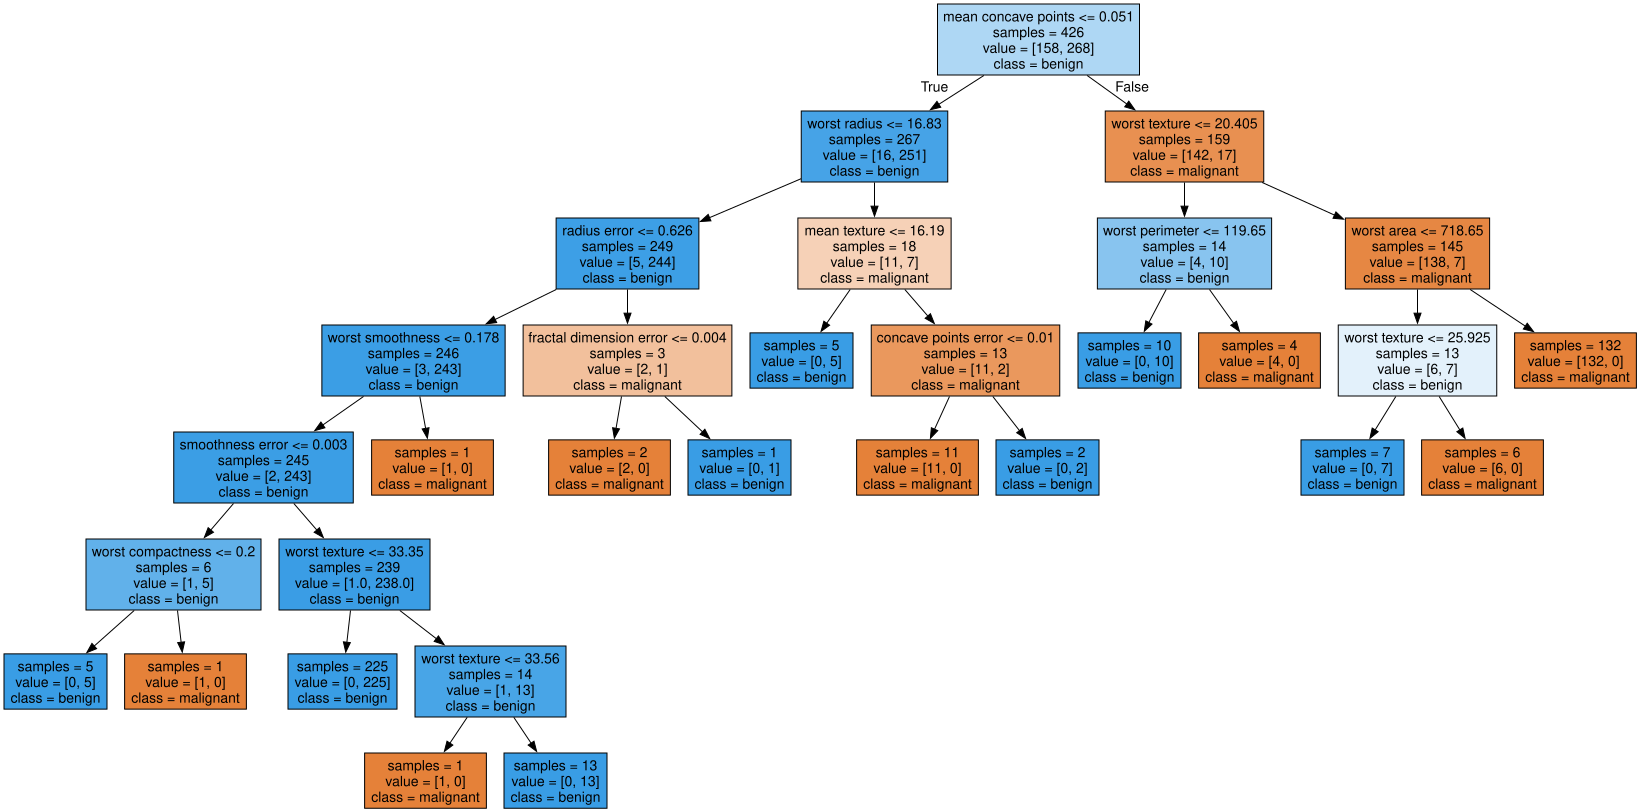

In [40]:
with open("bc_tree.dot") as f:
    temp = f.read()
graphviz.Source(temp)

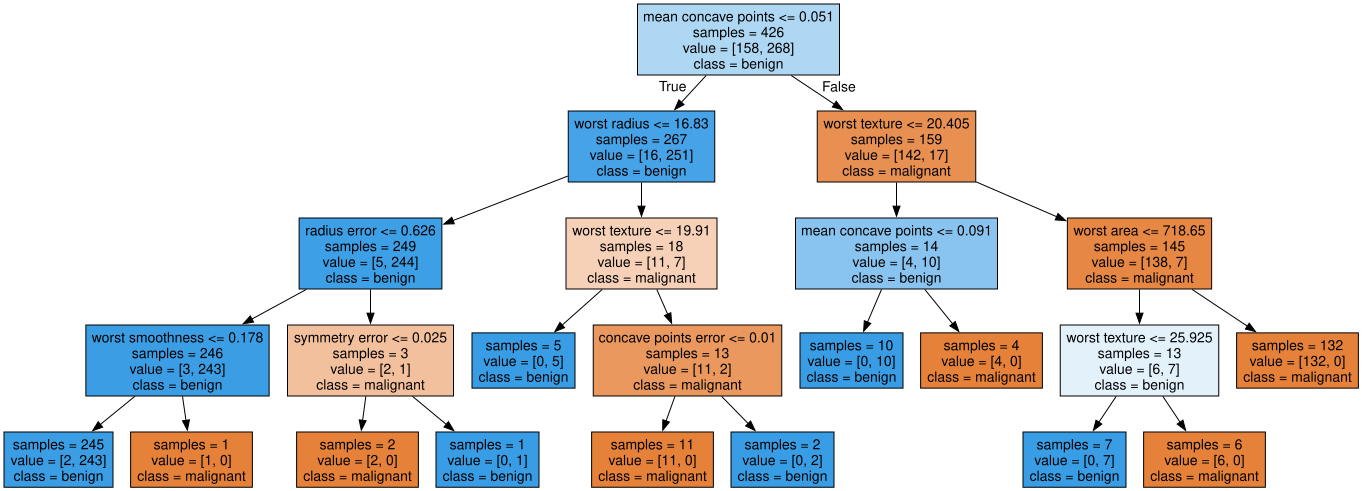

In [41]:
with open("bc_tree4.dot") as f:
    temp = f.read()
graphviz.Source(temp)

investigating feature importance

In [43]:
bc_model.feature_importances_

array([0.        , 0.02601101, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.69593688, 0.        , 0.        ,
       0.01277192, 0.        , 0.        , 0.        , 0.00155458,
       0.        , 0.        , 0.01702539, 0.        , 0.00670697,
       0.05899273, 0.09949554, 0.02874416, 0.03452044, 0.00985664,
       0.00838371, 0.        , 0.        , 0.        , 0.        ])

Text(0, 0.5, 'feature')

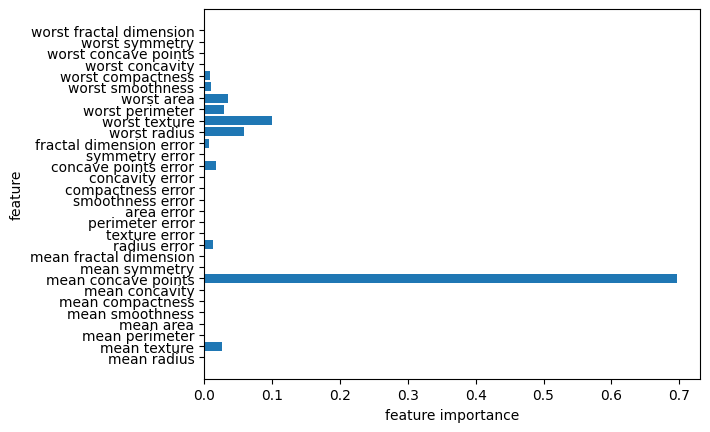

In [45]:
import matplotlib.pyplot as plt
import numpy as np
n_features = bc_data.data.shape[1]
plt.barh(range(n_features), bc_model.feature_importances_, align='center')
plt.yticks(np.arange(n_features), bc_data.feature_names)
plt.xlabel("feature importance")
plt.ylabel("feature")


# Random forest model classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier
rfc_cancer_model = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train, y_train)

In [48]:
print(f"test accuracy: {rfc_cancer_model.score(X_test, y_test)}")
print(f"train accuracy: {rfc_cancer_model.score(X_train, y_train)}")

test accuracy: 0.972027972027972
train accuracy: 1.0
